In [1]:
import os
if "KERAS_BACKEND" not in os.environ:                # ensure the backend is set
    os.environ["KERAS_BACKEND"] = "torch"

import math
import numpy as np  
import numba as nb
import seaborn as sns
import pandas as pd
import keras
import matplotlib.pyplot as plt
from pathlib import Path
from scipy.stats import truncnorm


import bayesflow as bf

import tensorflow as tf

#https://github.com/simschaefer/amortized-dmc

INFO:bayesflow:Using backend 'torch'
When using torch backend, we need to disable autograd by default to avoid excessive memory usage. Use

with torch.enable_grad():
    ...

in contexts where you need gradients (e.g. custom training loops).
/home/lisa/.pyenv/versions/3.11.7/envs/bfEnv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
I0000 00:00:1776930954.670284    7241 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [22]:
def mdmc_prior(): 
    # as in amortized_dmc.pdf, Updated $sd_r$ fixed (rounded values)
    lower = 0
    upper = np.inf

    means = np.array([360, 35, 60, 0.6, 20, 20, 120, 120])
    sds = np.array([25, 8, 13, 0.15, 8, 8, 40, 40])

    a = (lower - means) / sds
    b = (upper - means) / sds

    priors = truncnorm.rvs(a, b, loc=means, scale=sds)

    return dict(mu_r=priors[0], sd_r=priors[1], b=priors[2], muc=priors[3], 
                A1=priors[4], A2=priors[5], tau1=priors[6], tau2=priors[7])


def mdmc_trial(muc, A1, A2, tau1, tau2, b, ndts, noise, t, sigma = 4.0, dt = 1): 
    # Simulate multiple MDMC trials in parallel

    # Prepare output
    num_trials, _ = noise.shape
    rts = np.full(num_trials, -1.0)
    resps = np.full(num_trials, -1)

    X0 = np.random.beta(3, 3, size=num_trials) * (2 * b) - b    # initial pos

    sqrt_dt_sigma = sigma * np.sqrt(dt)

    # with a = 2
    mu_t = (A1 / tau1 * np.exp(1 - t / tau1) * (1 - t / tau1)) + (A2 / tau2 * np.exp(1 - t / tau2) * (1 - t / tau2)) + muc
    dX = mu_t[None, :] * dt + sqrt_dt_sigma * noise

    X = np.cumsum(dX, axis=1) #+ X0[:, None]

    crossed_upper = X >= b
    crossed_lower = X <= -b
    crossed_any = crossed_upper | crossed_lower

    # First crossing index for each trial
    first_crossing = np.argmax(crossed_any, axis=1)
    has_crossed = np.any(crossed_any, axis=1)

    # Fill only for trials that crossed
    idx = np.where(has_crossed)[0]
    crossing_times = t[first_crossing[idx]]


    ndts_crossed = ndts[idx]    # nondecision times only for trials that crossed
    rts[idx] = (crossing_times + ndts_crossed) / 1000  # convert to seconds

    # get response type
    resp_hit = X[idx, first_crossing[idx]]
    resps[idx] = (resp_hit >= b).astype(int)

    return np.c_[rts, resps]#, X, t


def mdmc_experiment(num_obs, muc, A1, A2, tau1, tau2, b, mu_r, sd_r): 
    max_time = 1500
    dt = 1

    # precompute time vector and noise
    t = np.linspace(start=dt, stop=max_time, num=int(max_time/dt))
    noise = np.random.normal(size = (num_obs, len(t)))
    ndts = np.random.normal(size = num_obs, loc=mu_r, scale=sd_r)

    out = np.zeros((num_obs, 2))        # to store rt and resp

    # congruency conditions (equal split)
    quarter = int(np.ceil(num_obs / 4)) + 1
    conditions = np.repeat(np.arange(4), quarter)[:num_obs]

    # simulate CONG-CONG trials (A1, A2)
    out[:quarter] = mdmc_trial(
        muc=muc, A1=A1, A2=A2, tau1=tau1, tau2=tau2, b=b, t=t, 
        ndts=ndts[:quarter], noise=noise[:quarter]
    )
    # simulate CONG-INCONG trials (A1, -A2)
    out[quarter:quarter*2] = mdmc_trial(
        muc=muc, A1=A1, A2=-A2, tau1=tau1, tau2=tau2, b=b, t=t, 
        ndts=ndts[quarter:quarter*2], noise=noise[quarter:quarter*2]
    )
    # simulate INCONG-CONG trials (-A1, A2)
    out[quarter*2:quarter*3] = mdmc_trial(
        muc=muc, A1=-A1, A2=A2, tau1=tau1, tau2=tau2, b=b, t=t, 
        ndts=ndts[quarter*2:quarter*3], noise=noise[quarter*2:quarter*3]
    )
    # simulate INCONG-INCONG trials (-A1, -A2)
    out[quarter*3:] = mdmc_trial(
        muc=muc, A1=-A1, A2=-A2, tau1=tau1, tau2=tau2, b=b, t=t, 
        ndts=ndts[quarter*3:], noise=noise[quarter*3:]
    )
    

    return dict(rt = out[:, 0], resp = out[:, 1], conditions = conditions, 
    num_obs = num_obs)

# Number of observations (trials) in each batch randomly sampled
def meta(batch_size, num_obs = None): 
    if num_obs == None:
        num_obs = np.random.randint(100, 300)
    return dict(num_obs = num_obs)
    
#num_obs = 2
#max_time = 1500
#dt = 1
#
#t = np.linspace(start=dt, stop=max_time, num=int(max_time/dt))  # time [ms]
#noise = np.random.normal(size = (num_obs, len(t)))
#ndts = np.random.normal(size = num_obs, loc=300, scale=0)
#
#mdmc_trial(muc=0.5, A1=20, A2=20, tau1=30, tau2=30, b=50, t=t, 
#           ndts=ndts, noise = noise)
#
#mdmc_experiment(num_obs = 50, muc = 0.5, A1 = 60, A2 = 60, 
#tau1 = 10, tau2 = 170, b = 50, mu_r = 300, sd_r = 36)



In [3]:
simulator = bf.simulators.make_simulator([mdmc_prior, mdmc_experiment], meta_fn = meta)

sim_data = simulator.sample(64)
print("Shape of rt:", sim_data["rt"].shape)
print("Shape of response:", sim_data["resp"].shape)
print("Shape of condition:", sim_data["conditions"].shape)

Shape of rt: (64, 221)
Shape of response: (64, 221)
Shape of condition: (64, 221)


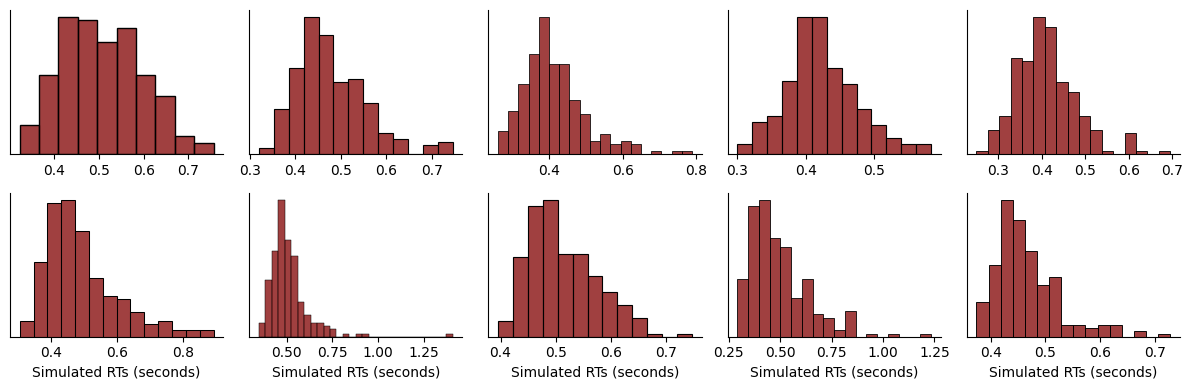

In [4]:
example_sim = simulator.sample(10)
f, axarr = plt.subplots(2, 5, figsize=(12, 4))
for i, ax in enumerate(axarr.flat):
    sns.histplot(example_sim["rt"][i].flatten(), color="maroon", alpha=0.75, ax=ax)
    sns.despine(ax=ax)
    ax.set_ylabel("")
    ax.set_yticks([])
    if i > 4:
        ax.set_xlabel("Simulated RTs (seconds)")
f.tight_layout()

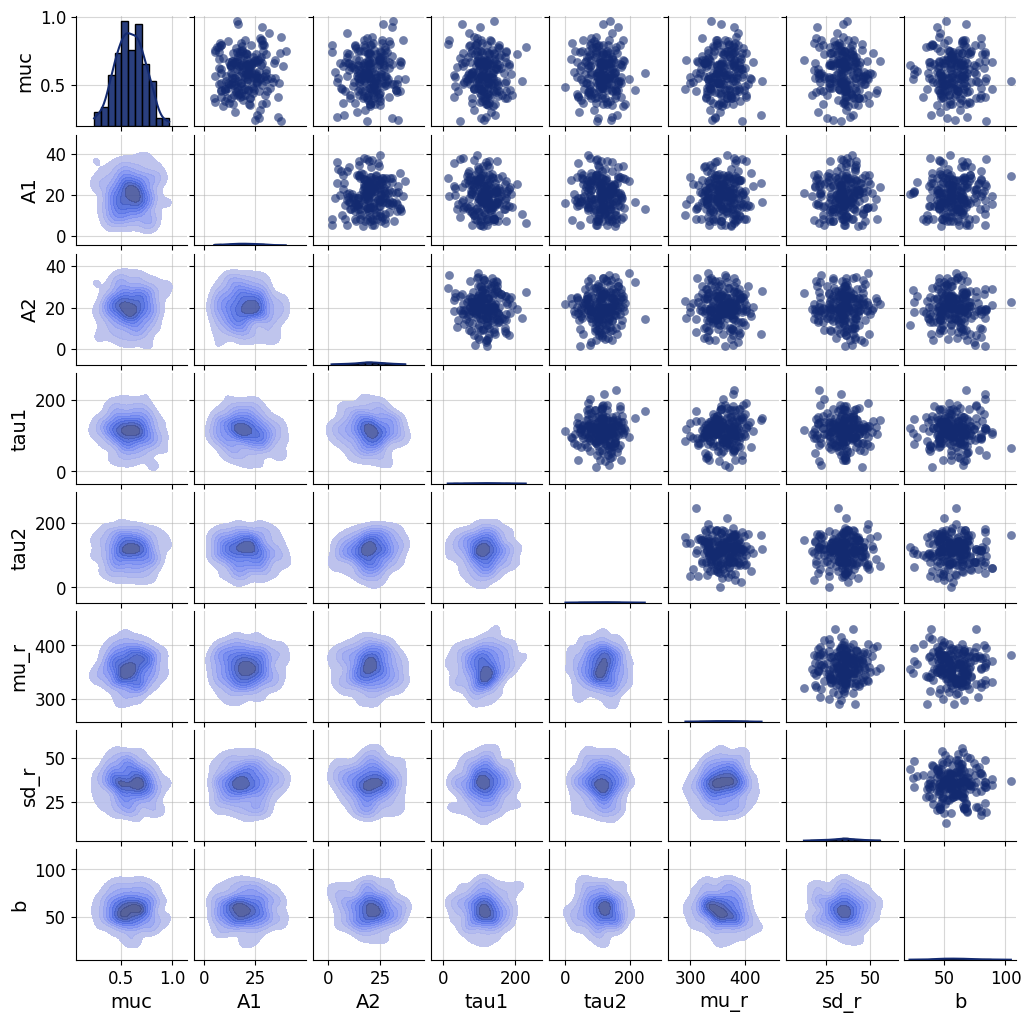

In [5]:
prior_samples = simulator.simulators[1].sample(200)

params = ["muc", "A1", "A2", "tau1", "tau2", "mu_r", "sd_r", "b"]
f = bf.diagnostics.pairs_samples(prior_samples, variable_keys=params)
f.fig.set_size_inches(10, 10)
# note: weird looking histograms also in SIR-example on https://github.com/bayesflow-org/bayesflow/blob/main/examples/SIR_Posterior_Estimation.ipynb

In [ ]:
adapter = (bf.Adapter()
    .convert_dtype("float64", "float32")
    .sqrt("num_obs")
    .as_set(["rt", "resp", "conditions"])
    .concatenate(
        ["muc", "A1", "A2", "tau1", "tau2", "mu_r", "sd_r", "b"], 
        into="inference_variables")
    .concatenate(["rt", "resp", "conditions"], into="summary_variables")
    .standardize(
        include="inference_variables", 
        mean=[0.6, 20, 20, 120, 120, 360, 35, 60], 
        std=[0.15, 8, 8, 40, 40, 360, 35, 60]
    )
    .rename("num_obs", "inference_conditions")
)

workflow = bf.BasicWorkflow(
    simulator=simulator,
    adapter=adapter,
    initial_learning_rate=5e-4,
    inference_network=bf.networks.FlowMatching(
        dropout=0.01070354852467715
    ),
    summary_network=bf.networks.SetTransformer(
        dropout=0.01070354852467715, 
        num_seeds=7, 
        summary_dim=24,             # 4 * dim of inference variables (4 * 1 * 8)
        embed_dims=(128, 128)
    ),
    inference_variables = ["muc", "A1", "A2", "tau1", "tau2", "mu_r", "sd_r", "b"],
    inference_conditions = ["num_obs"], 
    summary_variables = ["rt", "resp", "conditions"],
    checkpoint_filepath = Path(os.getcwd()).resolve(),  # save in cwd
    checkpoint_name = "MDMC_test"                 # file name
)

In [ ]:
num_samples = 500
val_sims = simulator.sample(200)

In [ ]:
#history = workflow.fit_offline(
#    data=train_data,
#    epochs=5, 
#    batch_size=32,
#    validation_data=validation_data
#)

In [ ]:
#approximator = keras.saving.load_model("keras-objects/MDMC_0504_big.keras")
approximator = keras.saving.load_model("keras-objects/MDMC_1704.keras")
print(approximator.summary())

Model: "continuous_approximator"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flow_matching (FlowMatching)    │ ?                      │       516,888 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ set_transformer                 │ (64, 22)               │       836,758 │
│ (SetTransformer)                │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ standardization_1               │ ?                      │            17 │
│ (Standardization)               │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,060,956 (15.49 MB)

 Trainable params: 1,353,646 (5.16 MB)

 Non-trainable params: 17 (68.00 B)

 Optimizer params: 2,707,293 (10.33 MB)

None


In [8]:
#post_draws = approximator.sample(conditions=val_sims, num_samples=num_samples)
post_draws = approximator.sample(conditions=val_sims, num_samples=10)

Sampling: 100%|██████████| 1/1 [00:30<00:00, 30.09s/batch]


In [9]:
print(str(post_draws))

{'muc': array([[[0.6384761 ],
        [0.70168878],
        [0.59212169],
        ...,
        [0.65863432],
        [0.6687367 ],
        [0.65556162]],

       [[0.6137124 ],
        [0.69190445],
        [0.68659532],
        ...,
        [0.64815498],
        [0.84892893],
        [0.75636756]],

       [[0.8209715 ],
        [0.865518  ],
        [0.83708838],
        ...,
        [0.99333276],
        [0.90267498],
        [0.91735414]],

       ...,

       [[0.57891857],
        [0.57754046],
        [0.58397999],
        ...,
        [0.61828826],
        [0.5995321 ],
        [0.62517297]],

       [[0.87944521],
        [0.83224497],
        [0.76942422],
        ...,
        [0.73102159],
        [0.7489791 ],
        [0.85566879]],

       [[0.60532416],
        [0.57247378],
        [0.61627197],
        ...,
        [0.56049739],
        [0.68296089],
        [0.62355741]]], shape=(200, 10, 1)), 'A1': array([[[32.8158102 ],
        [35.70465088],
        [29.26723671],
 

In [ ]:
log_densities = approximator.log_prob(data = simulator.sample(10))
print(log_densities) #TODO: ?? maybe wrong and maybe because of batching?

[-26.93230194 -33.47131676 -21.53902954 -22.62096542 -25.15962738
 -22.92816538 -22.27779669 -26.88561386 -24.22515482 -23.63215441]


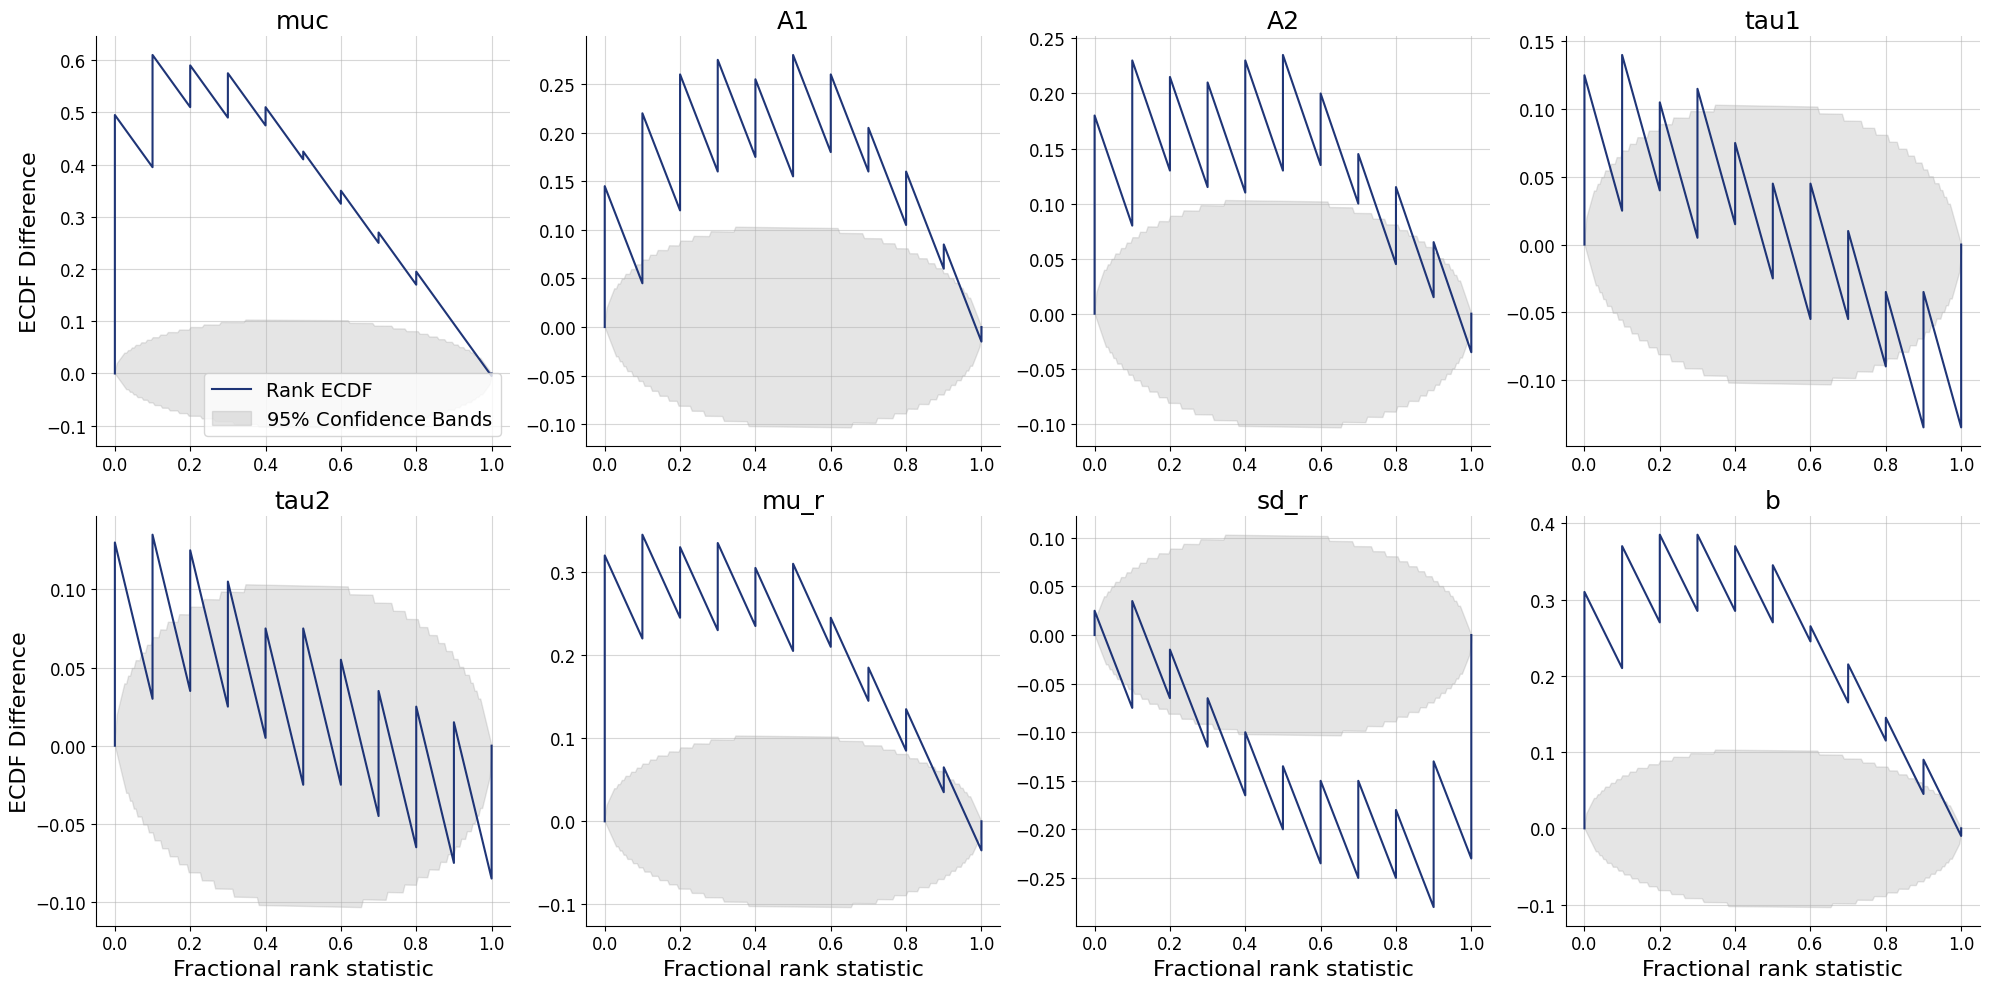

In [16]:
f = bf.diagnostics.plots.calibration_ecdf(
    estimates = post_draws, 
    targets = val_sims
)

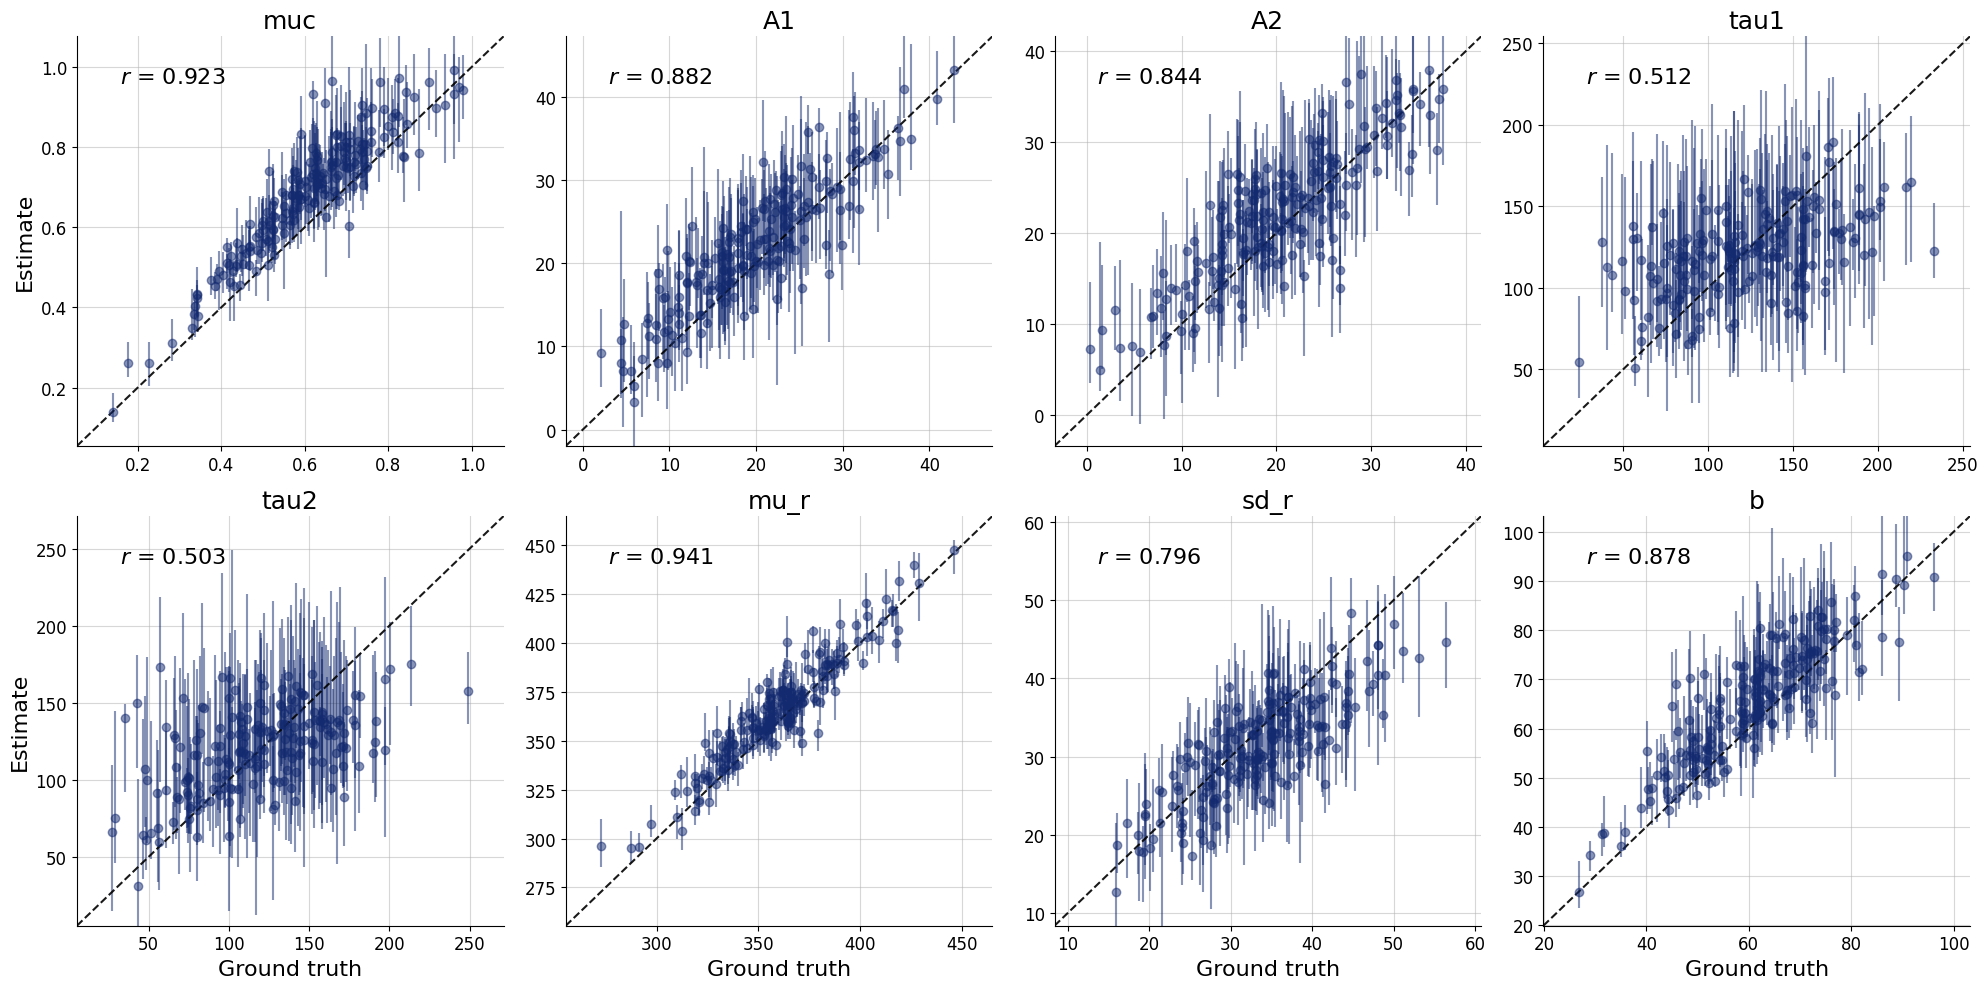

In [17]:
f = bf.diagnostics.plots.recovery(
    estimates = post_draws, 
    targets = val_sims
)

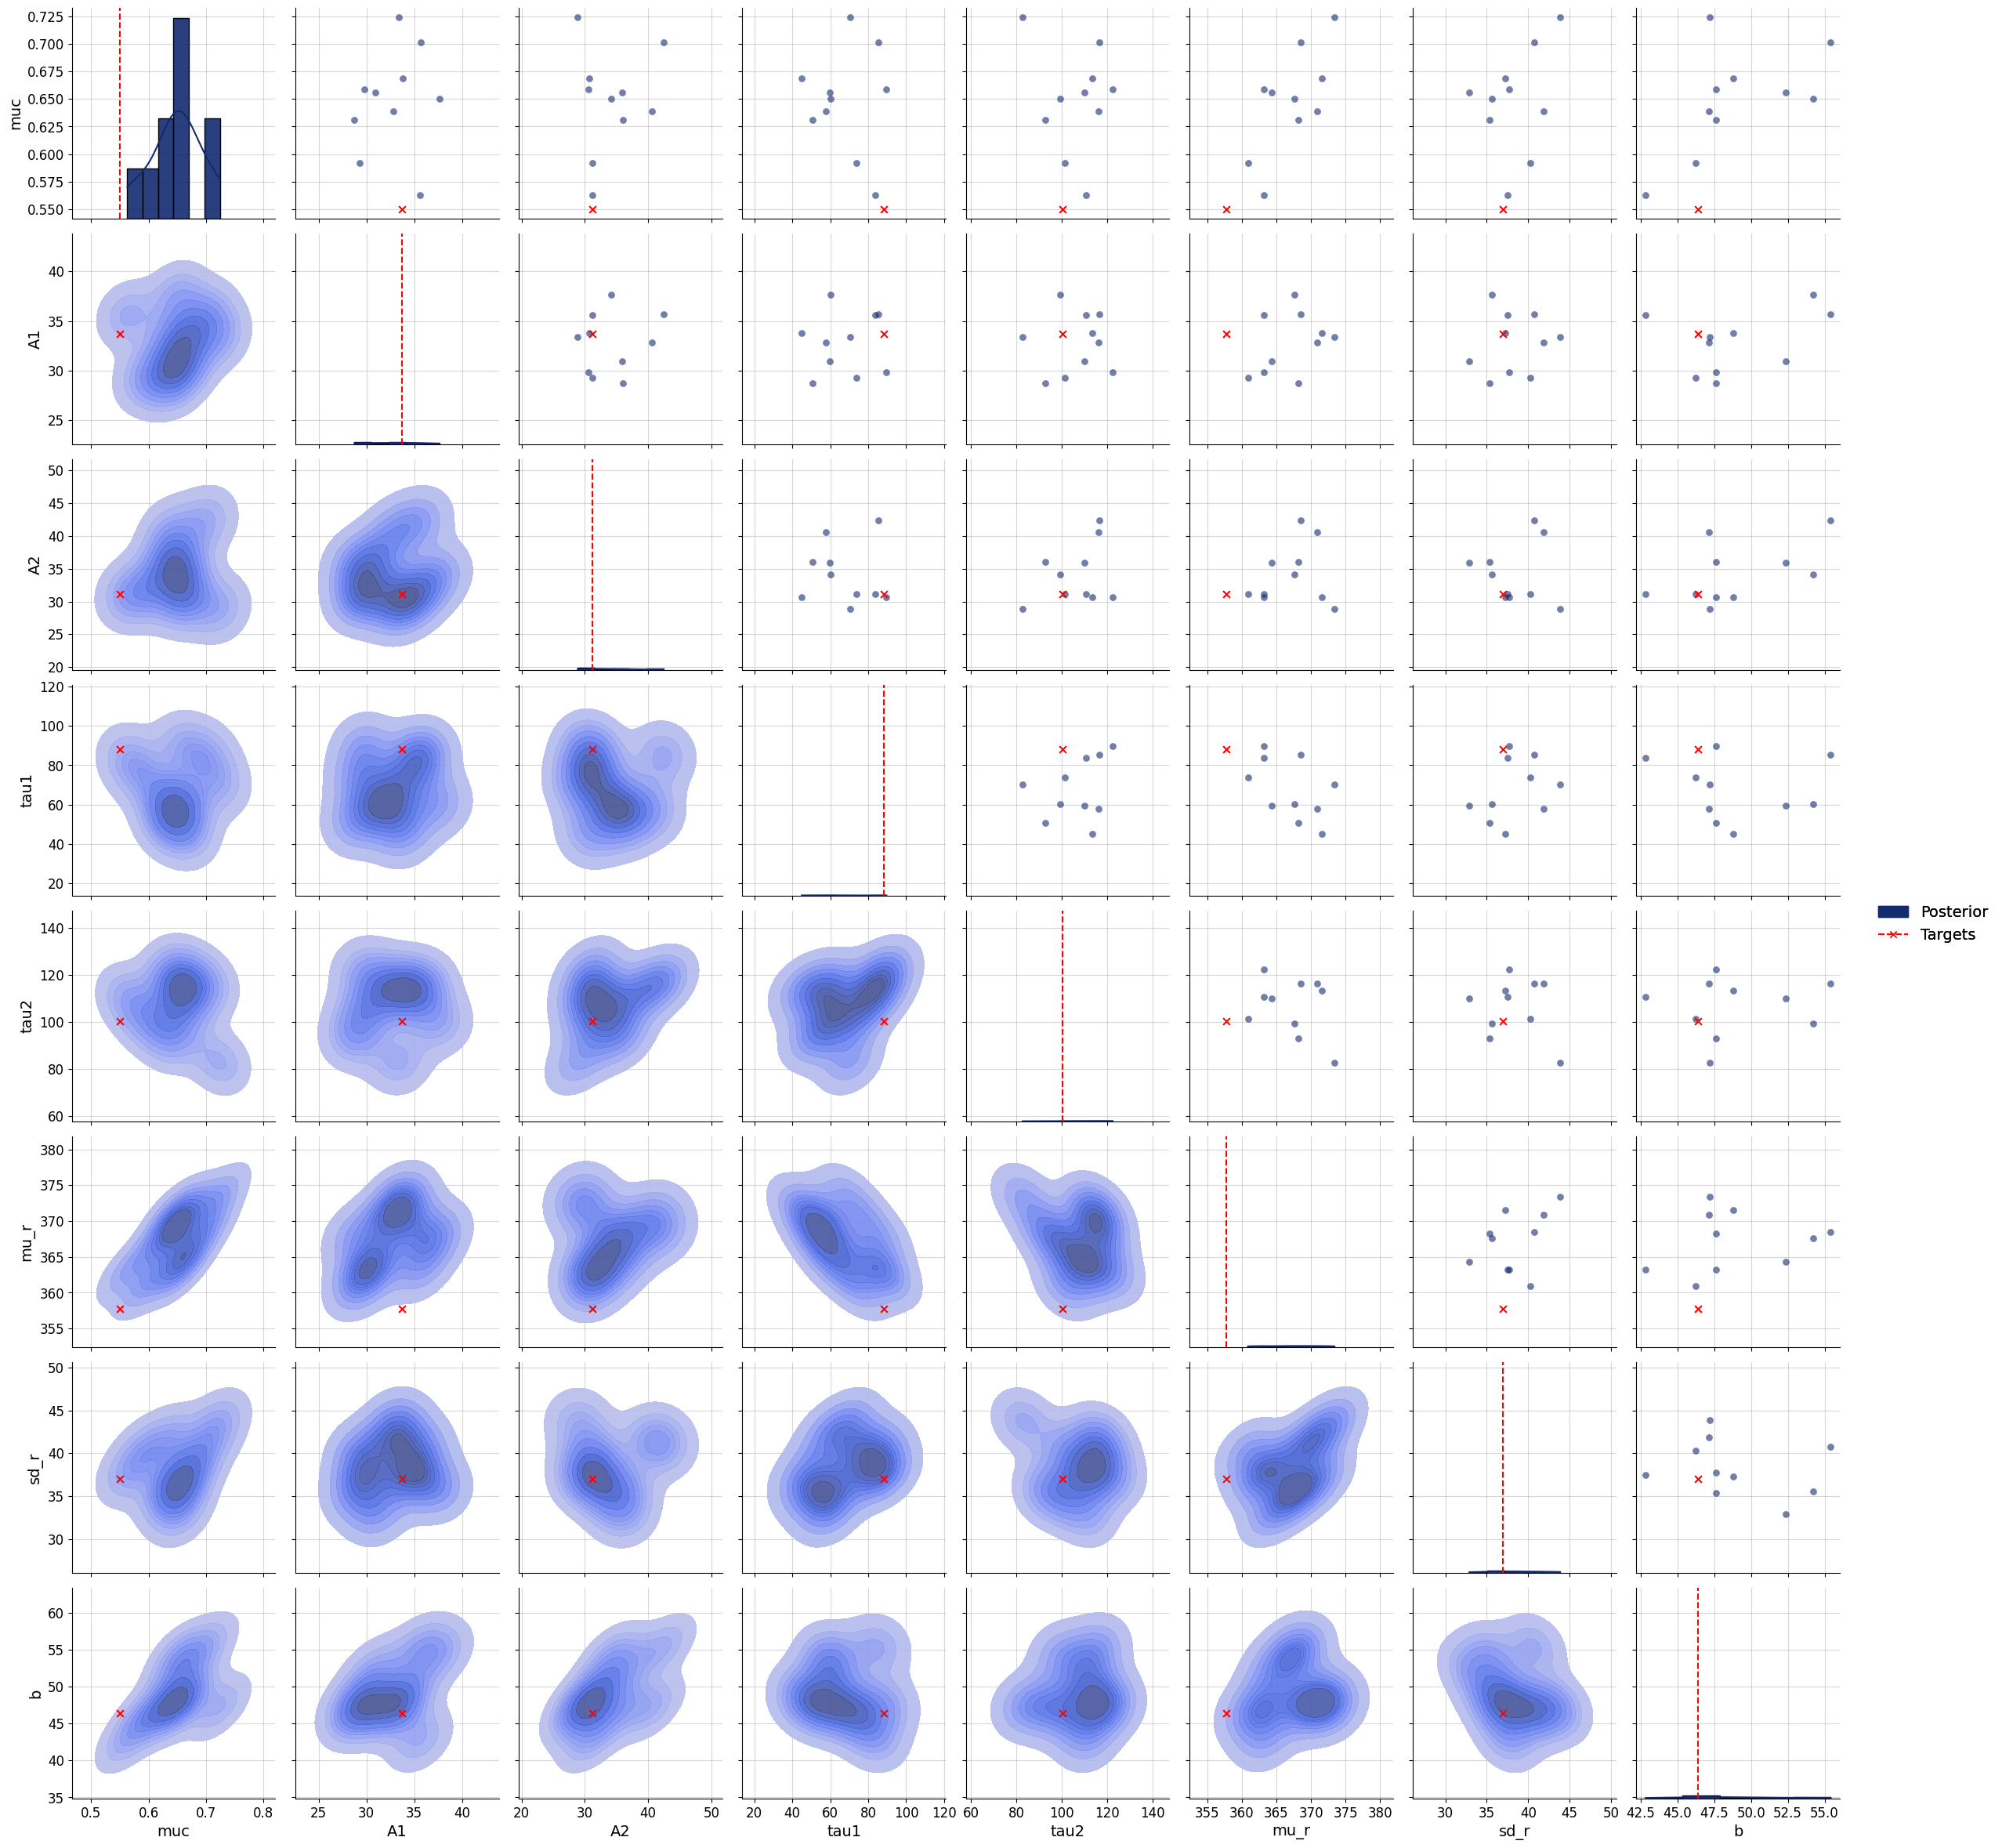

In [21]:
f = bf.diagnostics.plots.pairs_posterior(estimates=post_draws, targets = val_sims, dataset_id=0)

In [31]:
# load data
directory = "../data/Exp1a_data/combi/"
filelist = os.listdir(directory)

df = pd.concat(
    [pd.read_csv(os.path.join(directory, f), sep=r"\s+", header=None)
     for f in filelist],
    ignore_index=True
)

print(str(df))

# set colnames
# column names combi: “subj”, “block”, “catch”, “stimulus”, “stimuluscolor”, 
# “flankercolor”, “flanker”, “stroop”, “xr”, “r”, “corr”, “rt”, “re”
df.columns = ["subject", "block", "catch", "stimulus", 
"stimuluscolor", "flankercolor", "flanker", "stroop", "xr", "resp", "corr", "rt", 
"re"]
df.drop(['re', 'xr'], inplace=True, axis=1)

df = df.drop(df[df.catch == 1].index)           # remove catch trials

df["rt"] = df["rt"] / 1000.0      # convert to s

# separate condition columns for both processes
df["CI1"] = np.where(df["flanker"] == 0, "congruent", "incongruent") # Flanker
df["CI2"] = np.where(df["stroop"] == 0, "congruent", "incongruent")  # Stroop

# condition column both processes
df["CI"] = np.where(
    (df["CI1"] == "congruent") & (df["CI2"] == "congruent"), "CC",
    np.where(
        (df["CI1"] == "incongruent") & (df["CI2"] == "congruent"), "IC",
        np.where(
            (df["CI1"] == "congruent") & (df["CI2"] == "incongruent"), "CI", 
            "II"
        )
    )
)

       0   1   2   3   4   5   6   7   8   9   10    11  12
0      11   1   0   0   1   1   1   0   2   2   1  2712   1
1      11   1   0   0   0   2   0   1   1   1   1  1083   1
2      11   1   0   3   3   3   1   1   4   4   1   695   1
3      11   1   0   3   0   1   0   0   1   1   1  1082   0
4      11   1   0   2   3   3   1   0   4   4   1  1270   1
...    ..  ..  ..  ..  ..  ..  ..  ..  ..  ..  ..   ...  ..
18427  13   4   1   3   3   2   0   1   4   4   1   701   1
18428  13   4   0   3   3   3   1   1   4   4   1   728   1
18429  13   4   0   0   3   3   0   0   4   1   0   666   1
18430  13   4   0   0   3   3   1   0   4   4   1   900   1
18431  13   4   0   1   1   0   0   1   2   2   1   775   1

[18432 rows x 13 columns]


In [ ]:
df["conditions"] = df["CI"].astype("category").cat.codes
df_grouped = df.groupby(["subject", "CI"])

# min/max number of trials in any group
max_n = max(len(group) for _, group in df_grouped)
min_n = min(len(group) for _, group in df_grouped)
print(max_n, min_n)

# create dictionary, ensuring all data is stored as floats
data_inference_dict = {
    key: np.array([
        group[key].values.astype(float)[:min_n].reshape(min_n, 1)
        for _, group in df_grouped
    ])
    for key in ['rt', 'resp', 'conditions']
}

data_inference_dict["num_obs"] = np.sum(~np.isnan(data_inference_dict["rt"]), axis=1)

#print(data_inference_dict)
print({key: value.shape for key, value in data_inference_dict.items()}) # shapes




# check for NaNs
conds = data_inference_dict["conditions"]
rt = data_inference_dict["rt"]
resp = data_inference_dict["resp"]
print("NaN count:", np.isnan(conds).sum())
print("NaN count:", np.isnan(rt).sum())
print("NaN count:", np.isnan(resp).sum())

163 126
{'rt': (96, 126, 1), 'resp': (96, 126, 1), 'conditions': (96, 126, 1), 'num_obs': (96, 1)}
NaN count: 0
NaN count: 0
NaN count: 0


Sampling: 100%|██████████| 1/1 [01:54<00:00, 114.89s/batch]


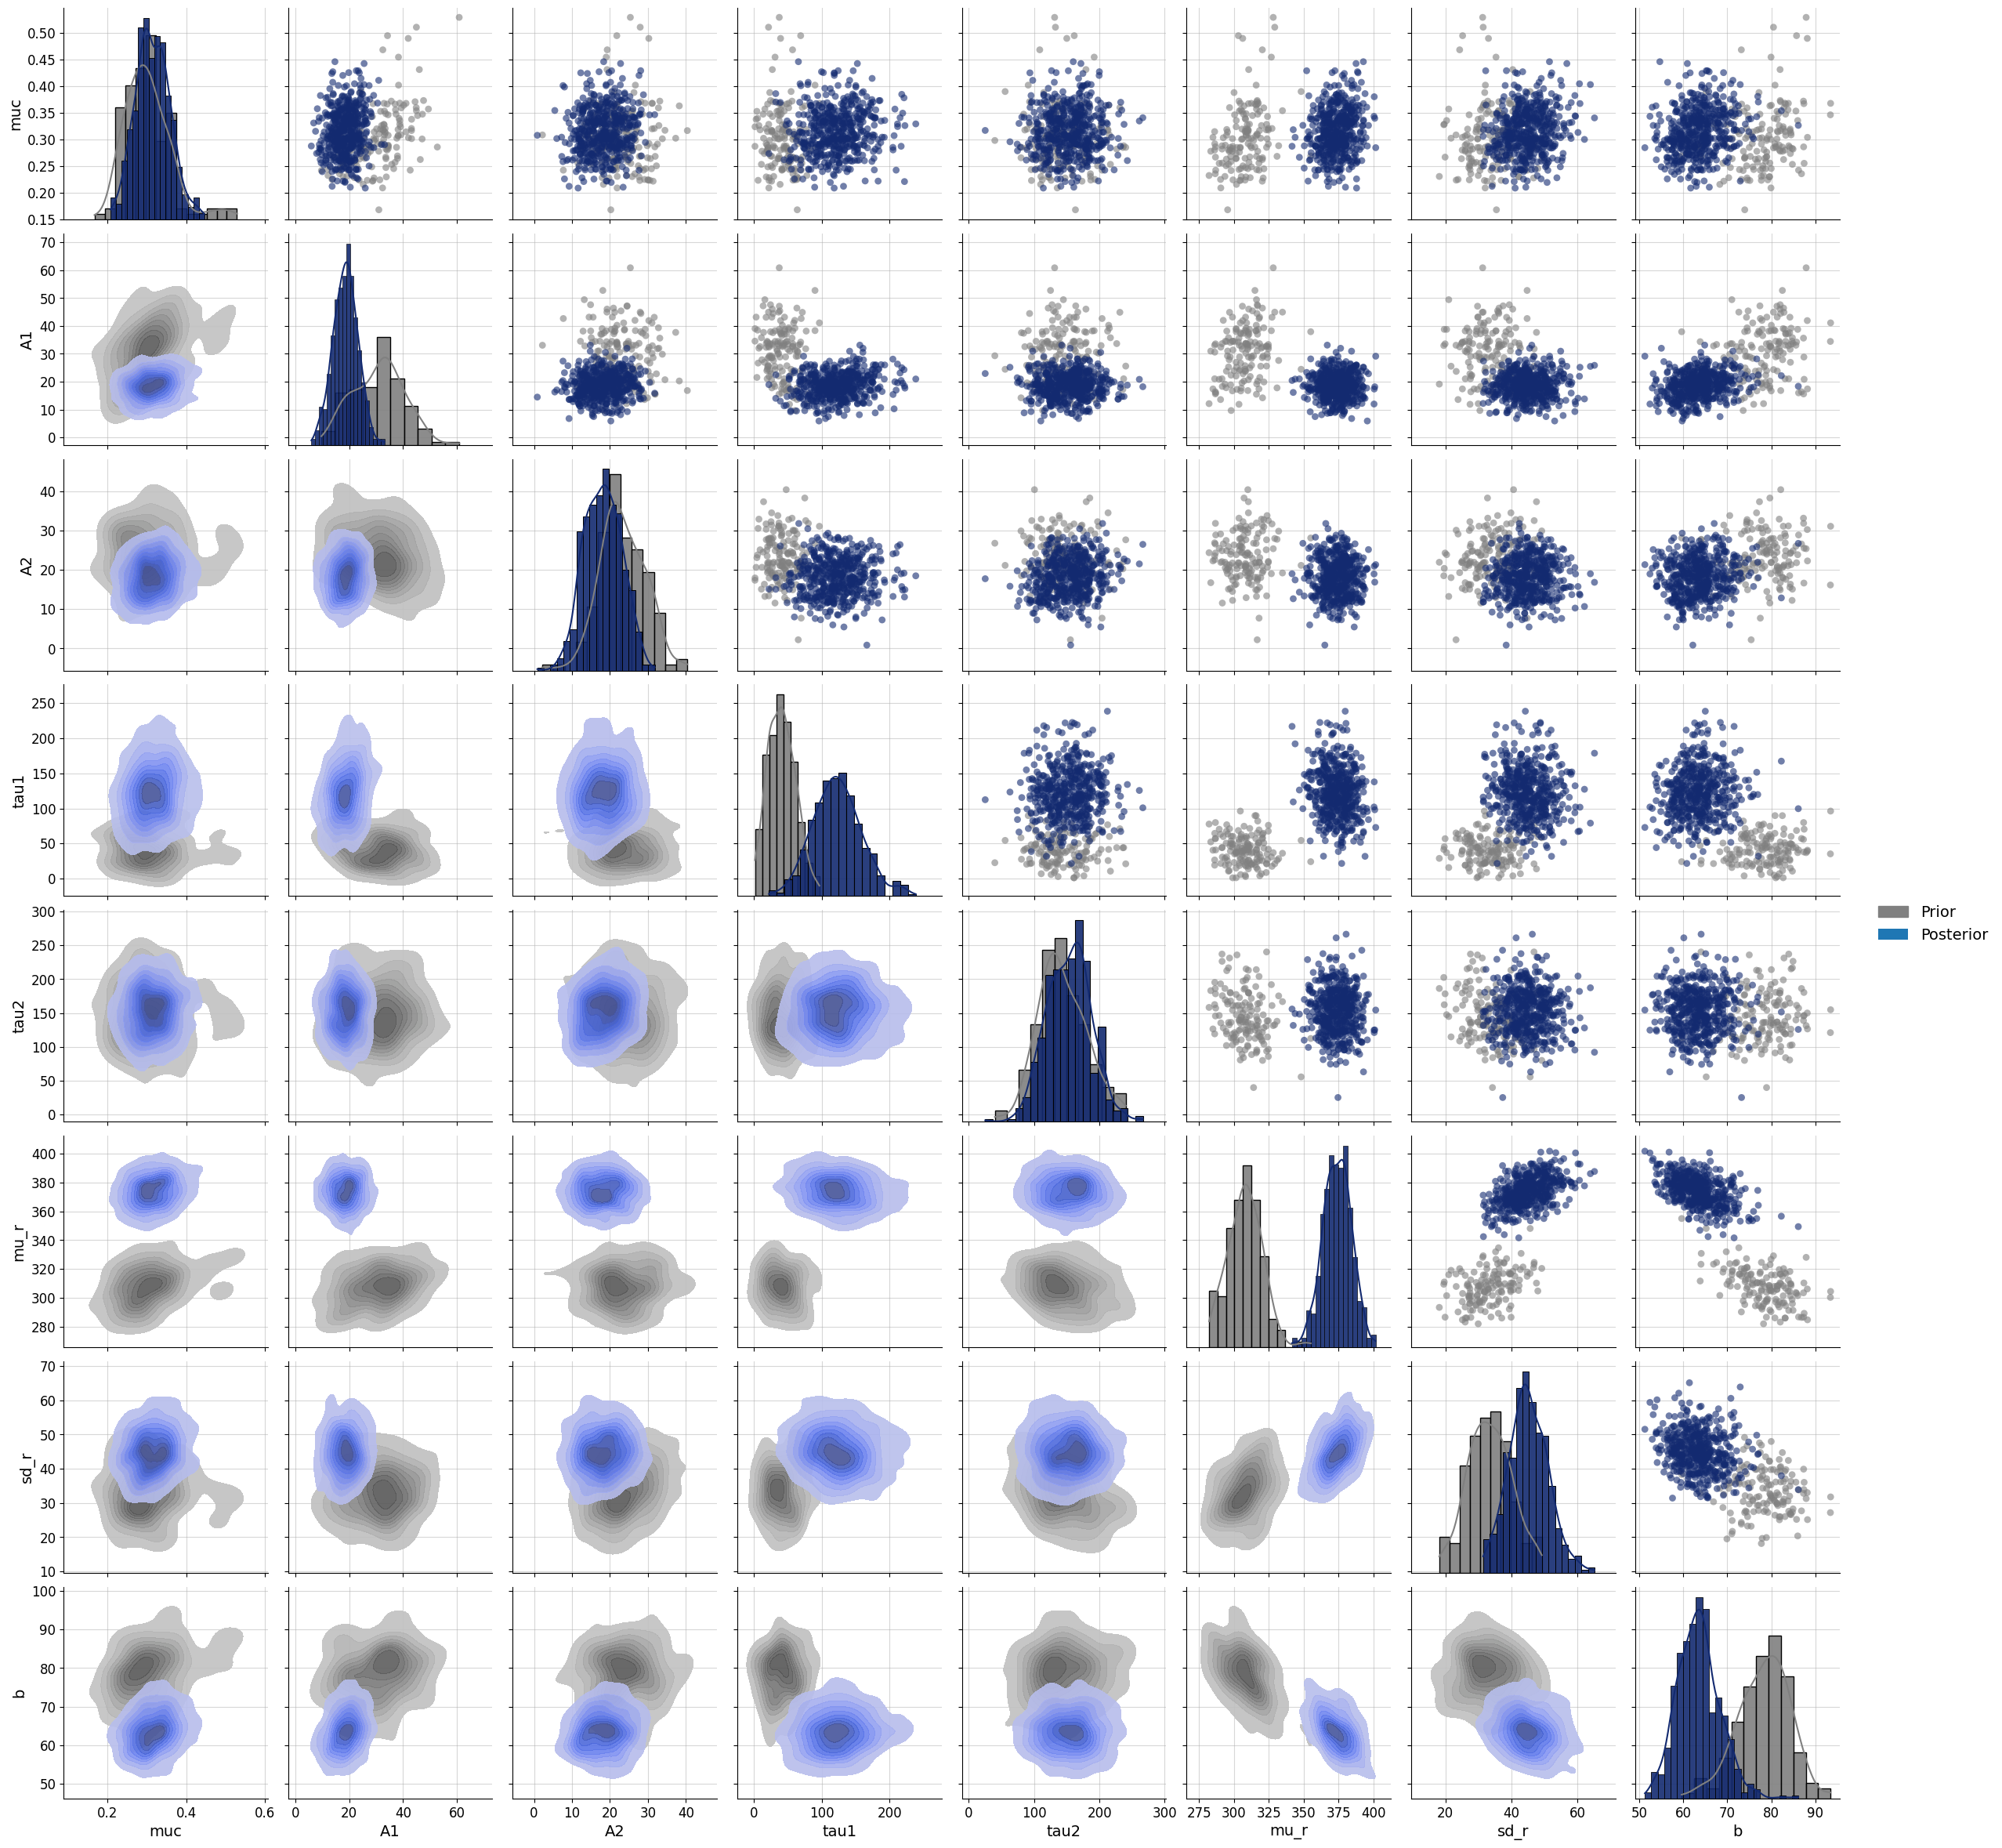

In [31]:
posterior = {key: value[0] for key, value in post_draws.items()}
test_data = approximator.sample(conditions = data_inference_dict, num_samples=150)
priors = dict(muc=test_data["muc"], A1=test_data["A1"], A2=test_data["A2"], 
                tau1=test_data["tau1"], tau2=test_data["tau2"], 
                mu_r=test_data["mu_r"], sd_r=test_data["sd_r"], 
                b=test_data["b"])
priors = {key: value[0] for key, value in priors.items()}
f=bf.diagnostics.pairs_posterior(estimates=posterior, priors=priors)

In [56]:

posterior = {key: value[0] for key, value in post_draws.items()}
print(posterior)

{'muc': array([[0.6384761 ],
       [0.70168878],
       [0.59212169],
       [0.56278836],
       [0.72403731],
       [0.65030258],
       [0.6309183 ],
       [0.65863432],
       [0.6687367 ],
       [0.65556162]]), 'A1': array([[32.8158102 ],
       [35.70465088],
       [29.26723671],
       [35.57789135],
       [33.34892368],
       [37.64728355],
       [28.75290966],
       [29.79066372],
       [33.81509495],
       [30.93411255]]), 'A2': array([[40.62222672],
       [42.40073395],
       [31.16255569],
       [31.19195652],
       [28.88109016],
       [34.14064026],
       [36.02990341],
       [30.61770153],
       [30.64026451],
       [35.90953541]]), 'tau1': array([[57.81082153],
       [85.2148819 ],
       [73.86853218],
       [83.77268553],
       [70.28775215],
       [60.34689426],
       [50.76582432],
       [89.60098028],
       [44.95690823],
       [59.59014416]]), 'tau2': array([[116.20275378],
       [116.40083075],
       [101.38530731],
       [110.68463

In [ ]:
#TODO: condition estimates

AttributeError: 'numpy.ndarray' object has no attribute 'items'